## import libraries 

In [43]:
import numpy as np 
import  pandas as pd
import re
import matplotlib.pyplot as plt
import seaborn as sns

## read the data

In [3]:
df=pd.read_excel('Desktop/DEPI/Datasets/Supply Chain shipment/Supply_Chain_Shipment_Pricing.xlsx')

In [41]:
df

,ID,Project Code,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,Product Group,Sub Classification,Vendor,Item Description,Molecule/Test Type,Brand,Dosage,Dosage Form,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Côte d'Ivoire,Program Management Office - US,Direct Drop,EX Works,Air,2006-06-02,2006-06-02,2006-06-02,Human Resource Digital Transformation,HIV test,RANBAXY Fine Chemicals LTD.,"HIV, Reveal G3 Rapid HIV-1 Antibody Test, 30 T...","HIV, Reveal G3 Rapid HIV-1 Antibody Test",Reveal,300mg,Test kit,30,19,551.00,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13.000000,780.340000,241.243885
1,3,108-VN-T01,Vietnam,Program Management Office - US,Direct Drop,EX Works,Air,2006-11-14,2006-11-14,2006-11-14,Antiretrovirals,Pediatric,Aurobindo Pharma Limited,"Nevirapine 10mg/ml, oral suspension, Bottle, 2...",Nevirapine,Generic,10mg/ml,Oral suspension,240,1000,6200.00,6.20,0.03,"Aurobindo Unit III, India",Yes,358.000000,4521.500000,241.243885
2,4,100-CI-T01,Côte d'Ivoire,Program Management Office - US,Direct Drop,Free Carrier,Air,2006-08-27,2006-08-27,2006-08-27,Human Resource Digital Transformation,HIV test,Abbott GmbH & Co. KG,"HIV 1/2, Determine Complete HIV Kit, 100 Tests","HIV 1/2, Determine Complete HIV Kit",Determine,300mg,Test kit,100,500,40000.00,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171.000000,1653.780000,241.243885
3,15,108-VN-T01,Vietnam,Program Management Office - US,Direct Drop,EX Works,Air,2006-09-01,2006-09-01,2006-09-01,Antiretrovirals,Adult,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,"Lamivudine 150mg, tablets, 60 Tabs",Lamivudine,Generic,150mg,Tablet,60,31920,127360.80,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855.000000,16007.060000,241.243885
4,16,108-VN-T01,Vietnam,Program Management Office - US,Direct Drop,EX Works,Air,2006-08-11,2006-08-11,2006-08-11,Antiretrovirals,Adult,Aurobindo Pharma Limited,"Stavudine 30mg, capsules, 60 Caps",Stavudine,Generic,30mg,Capsule,60,38000,121600.00,3.20,0.05,"Aurobindo Unit III, India",Yes,7590.000000,45450.080000,241.243885
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10319,86818,103-ZW-T30,Zimbabwe,Program Management Office - US,From RDC,N/A - From RDC,Truck,2015-07-31,2015-07-15,2015-07-20,Antiretrovirals,Pediatric,SCMS from RDC,"Lamivudine/Nevirapine/Zidovudine 30/50/60mg, d...",Lamivudine/Nevirapine/Zidovudine,Generic,30/50/60mg,Chewable/dispersible tablet - FDC,60,166571,599655.60,3.60,0.06,"Mylan, H-12 & H-13, India",No,25880.000000,46111.550000,705.790000
10320,86819,104-CI-T30,Côte d'Ivoire,Program Management Office - US,From RDC,N/A - From RDC,Truck,2015-07-31,2015-08-06,2015-08-07,Antiretrovirals,Adult,SCMS from RDC,"Lamivudine/Zidovudine 150/300mg, tablets, 60 Tabs",Lamivudine/Zidovudine,Generic,150/300mg,Tablet - FDC,60,21072,137389.44,6.52,0.11,Hetero Unit III Hyderabad IN,No,4426.000000,14734.920000,161.710000
10321,86821,110-ZM-T30,Zambia,Program Management Office - US,From RDC,N/A - From RDC,Truck,2015-08-31,2015-08-25,2015-09-03,Antiretrovirals,Adult,SCMS from RDC,Efavirenz/Lamivudine/Tenofovir Disoproxil Fuma...,Efavirenz/Lamivudine/Tenofovir Disoproxil Fuma...,Generic,600/300/300mg,Tablet - FDC,30,514526,5140114.74,9.99,0.33,Cipla Ltd A-42 MIDC Mahar. IN,No,4516.521007,12744.746161,5284.040000
10322,86822,200-ZW-T30,Zimbabwe,Program Management Office - US,From RDC,N/A - From RDC,Truck,2015-09-09,2015-08-04,2015-08-11,Antiretrovirals,Adult,SCMS from RDC,"Lamivudine/Zidovudine 150/300mg, tablets, 60 Tabs",Lamivudine/Zidovudine,Generic,150/300mg,Tablet - FDC,60,17465,113871.80,6.52,0.11,Mylan (formerly Matrix) Nashik,Yes,1392.000000,12744.746161,134.030000


In [5]:
df.shape

(10324, 33)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10324 entries, 0 to 10323
Data columns (total 33 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   ID                            10324 non-null  int64         
 1   Project Code                  10324 non-null  object        
 2   PQ #                          10324 non-null  object        
 3   PO / SO #                     10324 non-null  object        
 4   ASN/DN #                      10324 non-null  object        
 5   Country                       10324 non-null  object        
 6   Managed By                    10324 non-null  object        
 7   Fulfill Via                   10324 non-null  object        
 8   Vendor INCO Term              10324 non-null  object        
 9   Shipment Mode                 9964 non-null   object        
 10  PQ First Sent to Client Date  10324 non-null  object        
 11  PO Sent to Vendor Date      

In [7]:
pd.options.display.max_columns =None
df.head()

,ID,Project Code,PQ #,PO / SO #,ASN/DN #,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,PQ First Sent to Client Date,PO Sent to Vendor Date,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,Product Group,Sub Classification,Vendor,Item Description,Molecule/Test Type,Brand,Dosage,Dosage Form,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Pre-PQ Process,SCMS-4,ASN-8,Côte d'Ivoire,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,2006-06-02,2006-06-02,2006-06-02,HRDT,HIV test,RANBAXY Fine Chemicals LTD.,"HIV, Reveal G3 Rapid HIV-1 Antibody Test, 30 T...","HIV, Reveal G3 Rapid HIV-1 Antibody Test",Reveal,NaN,Test kit,30,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13,780.34,NaN
1,3,108-VN-T01,Pre-PQ Process,SCMS-13,ASN-85,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,2006-11-14,2006-11-14,2006-11-14,ARV,Pediatric,Aurobindo Pharma Limited,"Nevirapine 10mg/ml, oral suspension, Bottle, 2...",Nevirapine,Generic,10mg/ml,Oral suspension,240,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358,4521.5,NaN
2,4,100-CI-T01,Pre-PQ Process,SCMS-20,ASN-14,Côte d'Ivoire,PMO - US,Direct Drop,FCA,Air,Pre-PQ Process,Date Not Captured,2006-08-27,2006-08-27,2006-08-27,HRDT,HIV test,Abbott GmbH & Co. KG,"HIV 1/2, Determine Complete HIV Kit, 100 Tests","HIV 1/2, Determine Complete HIV Kit",Determine,NaN,Test kit,100,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171,1653.78,NaN
3,15,108-VN-T01,Pre-PQ Process,SCMS-78,ASN-50,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,2006-09-01,2006-09-01,2006-09-01,ARV,Adult,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,"Lamivudine 150mg, tablets, 60 Tabs",Lamivudine,Generic,150mg,Tablet,60,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855,16007.06,NaN
4,16,108-VN-T01,Pre-PQ Process,SCMS-81,ASN-55,Vietnam,PMO - US,Direct Drop,EXW,Air,Pre-PQ Process,Date Not Captured,2006-08-11,2006-08-11,2006-08-11,ARV,Adult,Aurobindo Pharma Limited,"Stavudine 30mg, capsules, 60 Caps",Stavudine,Generic,30mg,Capsule,60,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590,45450.08,NaN


## clean the data

* Replacement missing value and Drop columns

In [8]:
df.isna().sum()

ID                                 0
Project Code                       0
PQ #                               0
PO / SO #                          0
ASN/DN #                           0
Country                            0
Managed By                         0
Fulfill Via                        0
Vendor INCO Term                   0
Shipment Mode                    360
PQ First Sent to Client Date       0
PO Sent to Vendor Date             0
Scheduled Delivery Date            0
Delivered to Client Date           0
Delivery Recorded Date             0
Product Group                      0
Sub Classification                 0
Vendor                             0
Item Description                   0
Molecule/Test Type                 0
Brand                              0
Dosage                          1736
Dosage Form                        0
Unit of Measure (Per Pack)         0
Line Item Quantity                 0
Line Item Value                    0
Pack Price                         0
U

In [9]:
# Drop missing value in columns
df.dropna(subset=['Shipment Mode'], inplace=True)
df['Dosage']=df['Dosage'].fillna(df['Dosage'].mode()[0])
df['Line Item Insurance (USD)']=df['Line Item Insurance (USD)'].fillna(df['Line Item Insurance (USD)'].mean())

In [10]:
# Drop columns
df=df.drop(['PQ First Sent to Client Date','PO Sent to Vendor Date'],axis=1)
df=df.drop(['PQ #','PO / SO #','ASN/DN #'],axis=1)

In [11]:
df.isna().sum()

ID                            0
Project Code                  0
Country                       0
Managed By                    0
Fulfill Via                   0
Vendor INCO Term              0
Shipment Mode                 0
Scheduled Delivery Date       0
Delivered to Client Date      0
Delivery Recorded Date        0
Product Group                 0
Sub Classification            0
Vendor                        0
Item Description              0
Molecule/Test Type            0
Brand                         0
Dosage                        0
Dosage Form                   0
Unit of Measure (Per Pack)    0
Line Item Quantity            0
Line Item Value               0
Pack Price                    0
Unit Price                    0
Manufacturing Site            0
First Line Designation        0
Weight (Kilograms)            0
Freight Cost (USD)            0
Line Item Insurance (USD)     0
dtype: int64

In [47]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
ID,9864.0,52915.653082,1.0,16956.75,61717.5,83791.25,86823.0,31438.431142
Scheduled Delivery Date,9864,2011-12-05 12:12:59.562043392,2006-05-02 00:00:00,2009-11-30 00:00:00,2012-02-29 00:00:00,2014-01-22 00:00:00,2015-12-31 00:00:00,NaN
Delivered to Client Date,9864,2011-11-29 08:35:37.226277120,2006-05-02 00:00:00,2009-11-29 06:00:00,2012-02-14 00:00:00,2014-01-24 00:00:00,2015-09-14 00:00:00,NaN
Delivery Recorded Date,9864,2011-12-02 06:43:03.941605888,2006-05-02 00:00:00,2009-11-29 06:00:00,2012-02-14 00:00:00,2014-02-06 00:00:00,2015-09-14 00:00:00,NaN
Unit of Measure (Per Pack),9864.0,77.134327,1.0,30.0,60.0,90.0,1000.0,76.438504
Line Item Quantity,9864.0,18784.848743,1.0,416.0,3073.0,17760.0,619999.0,40741.340303
Line Item Value,9864.0,160910.086268,2.0,4628.375,31465.37,170617.01,5951990.4,350738.224073
Pack Price,9864.0,21.951285,0.39,4.22,9.3,23.5,1345.64,45.888919
Unit Price,9864.0,0.596099,0.01,0.08,0.16,0.47,41.68,2.303495
Weight (Kilograms),9864.0,4534.447614,1.0,404.75,2156.0,4516.521007,857354.0,12493.259043


In [45]:
df=df[(df[['Line Item Value','Pack Price','Unit Price','Weight (Kilograms)']]!=0).all(axis =1)]
df

,ID,Project Code,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,Product Group,Sub Classification,Vendor,Item Description,Molecule/Test Type,Brand,Dosage,Dosage Form,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Côte d'Ivoire,Program Management Office - US,Direct Drop,EX Works,Air,2006-06-02,2006-06-02,2006-06-02,Human Resource Digital Transformation,HIV test,RANBAXY Fine Chemicals LTD.,"HIV, Reveal G3 Rapid HIV-1 Antibody Test, 30 T...","HIV, Reveal G3 Rapid HIV-1 Antibody Test",Reveal,300mg,Test kit,30,19,551.00,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13.000000,780.340000,241.243885
1,3,108-VN-T01,Vietnam,Program Management Office - US,Direct Drop,EX Works,Air,2006-11-14,2006-11-14,2006-11-14,Antiretrovirals,Pediatric,Aurobindo Pharma Limited,"Nevirapine 10mg/ml, oral suspension, Bottle, 2...",Nevirapine,Generic,10mg/ml,Oral suspension,240,1000,6200.00,6.20,0.03,"Aurobindo Unit III, India",Yes,358.000000,4521.500000,241.243885
2,4,100-CI-T01,Côte d'Ivoire,Program Management Office - US,Direct Drop,Free Carrier,Air,2006-08-27,2006-08-27,2006-08-27,Human Resource Digital Transformation,HIV test,Abbott GmbH & Co. KG,"HIV 1/2, Determine Complete HIV Kit, 100 Tests","HIV 1/2, Determine Complete HIV Kit",Determine,300mg,Test kit,100,500,40000.00,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171.000000,1653.780000,241.243885
3,15,108-VN-T01,Vietnam,Program Management Office - US,Direct Drop,EX Works,Air,2006-09-01,2006-09-01,2006-09-01,Antiretrovirals,Adult,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,"Lamivudine 150mg, tablets, 60 Tabs",Lamivudine,Generic,150mg,Tablet,60,31920,127360.80,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855.000000,16007.060000,241.243885
4,16,108-VN-T01,Vietnam,Program Management Office - US,Direct Drop,EX Works,Air,2006-08-11,2006-08-11,2006-08-11,Antiretrovirals,Adult,Aurobindo Pharma Limited,"Stavudine 30mg, capsules, 60 Caps",Stavudine,Generic,30mg,Capsule,60,38000,121600.00,3.20,0.05,"Aurobindo Unit III, India",Yes,7590.000000,45450.080000,241.243885
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10319,86818,103-ZW-T30,Zimbabwe,Program Management Office - US,From RDC,N/A - From RDC,Truck,2015-07-31,2015-07-15,2015-07-20,Antiretrovirals,Pediatric,SCMS from RDC,"Lamivudine/Nevirapine/Zidovudine 30/50/60mg, d...",Lamivudine/Nevirapine/Zidovudine,Generic,30/50/60mg,Chewable/dispersible tablet - FDC,60,166571,599655.60,3.60,0.06,"Mylan, H-12 & H-13, India",No,25880.000000,46111.550000,705.790000
10320,86819,104-CI-T30,Côte d'Ivoire,Program Management Office - US,From RDC,N/A - From RDC,Truck,2015-07-31,2015-08-06,2015-08-07,Antiretrovirals,Adult,SCMS from RDC,"Lamivudine/Zidovudine 150/300mg, tablets, 60 Tabs",Lamivudine/Zidovudine,Generic,150/300mg,Tablet - FDC,60,21072,137389.44,6.52,0.11,Hetero Unit III Hyderabad IN,No,4426.000000,14734.920000,161.710000
10321,86821,110-ZM-T30,Zambia,Program Management Office - US,From RDC,N/A - From RDC,Truck,2015-08-31,2015-08-25,2015-09-03,Antiretrovirals,Adult,SCMS from RDC,Efavirenz/Lamivudine/Tenofovir Disoproxil Fuma...,Efavirenz/Lamivudine/Tenofovir Disoproxil Fuma...,Generic,600/300/300mg,Tablet - FDC,30,514526,5140114.74,9.99,0.33,Cipla Ltd A-42 MIDC Mahar. IN,No,4516.521007,12744.746161,5284.040000
10322,86822,200-ZW-T30,Zimbabwe,Program Management Office - US,From RDC,N/A - From RDC,Truck,2015-09-09,2015-08-04,2015-08-11,Antiretrovirals,Adult,SCMS from RDC,"Lamivudine/Zidovudine 150/300mg, tablets, 60 Tabs",Lamivudine/Zidovudine,Generic,150/300mg,Tablet - FDC,60,17465,113871.80,6.52,0.11,Mylan (formerly Matrix) Nashik,Yes,1392.000000,12744.746161,134.030000


* Replace 

In [12]:
## Check how many values to Replace
df['Managed By'].value_counts()

Managed By
PMO - US                     9905
South Africa Field Office      57
Haiti Field Office              1
Ethiopia Field Office           1
Name: count, dtype: int64

In [13]:
## Replace values in 'maneged by' column
df['Managed By']=df['Managed By'].replace('PMO - US','Program Management Office - US')

In [14]:
df['Managed By'].value_counts()

Managed By
Program Management Office - US    9905
South Africa Field Office           57
Haiti Field Office                   1
Ethiopia Field Office                1
Name: count, dtype: int64

In [15]:
## Check how many values to Replace
df['Vendor INCO Term'].value_counts()# RDC =Regional Distribution Centers

Vendor INCO Term
N/A - From RDC    5092
EXW               2778
DDP               1399
FCA                397
CIP                273
DDU                 14
DAP                  9
CIF                  2
Name: count, dtype: int64

In [16]:
## Create a dictionary 
Vendor_INCO_dictionary={
    'EXW':'EX Works',
    'DDP':'Delivered Duty Paid',
    'FCA':'Free Carrier',
    'CIP': 'Carriage and Insurance Paid To',
    'DDU':'Delivered Duty Unpaid',
    'DAP':'Delivered at Place',
    'CIF':'Cost Insurance and Freight'}

In [17]:
## Replace values in 'Vendor INCO Term' column
df['Vendor INCO Term']=df['Vendor INCO Term'].replace(Vendor_INCO_dictionary)

In [18]:
df['Vendor INCO Term'].value_counts()

Vendor INCO Term
N/A - From RDC                    5092
EX Works                          2778
Delivered Duty Paid               1399
Free Carrier                       397
Carriage and Insurance Paid To     273
Delivered Duty Unpaid               14
Delivered at Place                   9
Cost Insurance and Freight           2
Name: count, dtype: int64

In [22]:
## Check how many values to Replace
df['Product Group'].value_counts()

Product Group
Antiretrovirals                          8241
Human Resource Digital Transformation    1678
Antimalarial medication                    22
ACT                                        16
Malaria Rapid Diagnostic Test               7
Name: count, dtype: int64

In [20]:
## Create dictionary for product group
product_group_dic={
    'HRDT':'Human Resource Digital Transformation',
    'ARV':'Antiretrovirals',
    'ANTM':'Antimalarial medication',
    'MRDT':'Malaria Rapid Diagnostic Test'}

In [21]:
## Repalce values in product group column 
df['Product Group']=df['Product Group'].replace(product_group_dic)

In [23]:
def replace_references_using_id_and_dn(row, id_df):
    
    if isinstance(row['Weight (Kilograms)'], str) and ('See ASN' in row['Weight (Kilograms)'] or 'See DN' in row['Weight (Kilograms)']):
        id_match = re.search(r'ID#:(\d+)', row['Weight (Kilograms)'])
        if id_match:
            id_ref = int(id_match.group(1))  
            id_value = id_df.loc[id_df['ID'] == id_ref, 'Weight (Kilograms)'].values
            if len(id_value) > 0:
                row['Weight (Kilograms)'] = id_value[0]  # Replace with actual weight
    
    if isinstance(row['Freight Cost (USD)'], str) and ('See ASN' in row['Freight Cost (USD)'] or 'See DN' in row['Freight Cost (USD)']):
        id_match = re.search(r'ID#:(\d+)', row['Freight Cost (USD)'])
        if id_match:
            id_ref = int(id_match.group(1))  
            id_value = id_df.loc[id_df['ID'] == id_ref, 'Freight Cost (USD)'].values
            if len(id_value) > 0:
                row['Freight Cost (USD)'] = id_value[0]  

    return row  

In [24]:
df= df.apply(lambda row: replace_references_using_id_and_dn(row, df), axis=1)

In [39]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9964 entries, 0 to 10323
Data columns (total 28 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   ID                          9964 non-null   int64         
 1   Project Code                9964 non-null   object        
 2   Country                     9964 non-null   object        
 3   Managed By                  9964 non-null   object        
 4   Fulfill Via                 9964 non-null   object        
 5   Vendor INCO Term            9964 non-null   object        
 6   Shipment Mode               9964 non-null   object        
 7   Scheduled Delivery Date     9964 non-null   datetime64[ns]
 8   Delivered to Client Date    9964 non-null   datetime64[ns]
 9   Delivery Recorded Date      9964 non-null   datetime64[ns]
 10  Product Group               9964 non-null   object        
 11  Sub Classification          9964 non-null   object        
 

In [26]:
# List of numerical columns to convert
numeric_cols = [
    'Freight Cost (USD)',
    'Weight (Kilograms)'
]

# Convert columns to numeric types
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')


In [38]:
date_columns = ['Scheduled Delivery Date', 'Delivered to Client Date', 'Delivery Recorded Date']
for col in date_columns:
    df[col] = pd.to_datetime(df[col], errors='coerce')

In [48]:
df.isna().sum()

ID                            0
Project Code                  0
Country                       0
Managed By                    0
Fulfill Via                   0
Vendor INCO Term              0
Shipment Mode                 0
Scheduled Delivery Date       0
Delivered to Client Date      0
Delivery Recorded Date        0
Product Group                 0
Sub Classification            0
Vendor                        0
Item Description              0
Molecule/Test Type            0
Brand                         0
Dosage                        0
Dosage Form                   0
Unit of Measure (Per Pack)    0
Line Item Quantity            0
Line Item Value               0
Pack Price                    0
Unit Price                    0
Manufacturing Site            0
First Line Designation        0
Weight (Kilograms)            0
Freight Cost (USD)            0
Line Item Insurance (USD)     0
dtype: int64

In [28]:
# Replace null in weight and line item insurance 
df['Weight (Kilograms)']=df['Weight (Kilograms)'].fillna(df['Weight (Kilograms)'].mean())
df['Freight Cost (USD)']=df['Freight Cost (USD)'].fillna(df['Freight Cost (USD)'].mean())

In [29]:
df.isna().sum()

ID                            0
Project Code                  0
Country                       0
Managed By                    0
Fulfill Via                   0
Vendor INCO Term              0
Shipment Mode                 0
Scheduled Delivery Date       0
Delivered to Client Date      0
Delivery Recorded Date        0
Product Group                 0
Sub Classification            0
Vendor                        0
Item Description              0
Molecule/Test Type            0
Brand                         0
Dosage                        0
Dosage Form                   0
Unit of Measure (Per Pack)    0
Line Item Quantity            0
Line Item Value               0
Pack Price                    0
Unit Price                    0
Manufacturing Site            0
First Line Designation        0
Weight (Kilograms)            0
Freight Cost (USD)            0
Line Item Insurance (USD)     0
dtype: int64

## EDA

In [49]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
ID,9864.0,52915.653082,1.0,16956.75,61717.5,83791.25,86823.0,31438.431142
Scheduled Delivery Date,9864,2011-12-05 12:12:59.562043392,2006-05-02 00:00:00,2009-11-30 00:00:00,2012-02-29 00:00:00,2014-01-22 00:00:00,2015-12-31 00:00:00,NaN
Delivered to Client Date,9864,2011-11-29 08:35:37.226277120,2006-05-02 00:00:00,2009-11-29 06:00:00,2012-02-14 00:00:00,2014-01-24 00:00:00,2015-09-14 00:00:00,NaN
Delivery Recorded Date,9864,2011-12-02 06:43:03.941605888,2006-05-02 00:00:00,2009-11-29 06:00:00,2012-02-14 00:00:00,2014-02-06 00:00:00,2015-09-14 00:00:00,NaN
Unit of Measure (Per Pack),9864.0,77.134327,1.0,30.0,60.0,90.0,1000.0,76.438504
Line Item Quantity,9864.0,18784.848743,1.0,416.0,3073.0,17760.0,619999.0,40741.340303
Line Item Value,9864.0,160910.086268,2.0,4628.375,31465.37,170617.01,5951990.4,350738.224073
Pack Price,9864.0,21.951285,0.39,4.22,9.3,23.5,1345.64,45.888919
Unit Price,9864.0,0.596099,0.01,0.08,0.16,0.47,41.68,2.303495
Weight (Kilograms),9864.0,4534.447614,1.0,404.75,2156.0,4516.521007,857354.0,12493.259043


In [92]:
df.head()

,ID,Project Code,Country,Managed By,Fulfill Via,Vendor INCO Term,Shipment Mode,Scheduled Delivery Date,Delivered to Client Date,Delivery Recorded Date,Product Group,Sub Classification,Vendor,Item Description,Molecule/Test Type,Brand,Dosage,Dosage Form,Unit of Measure (Per Pack),Line Item Quantity,Line Item Value,Pack Price,Unit Price,Manufacturing Site,First Line Designation,Weight (Kilograms),Freight Cost (USD),Line Item Insurance (USD)
0,1,100-CI-T01,Côte d'Ivoire,Program Management Office - US,Direct Drop,EX Works,Air,2006-06-02,2006-06-02,2006-06-02,Human Resource Digital Transformation,HIV test,RANBAXY Fine Chemicals LTD.,"HIV, Reveal G3 Rapid HIV-1 Antibody Test, 30 T...","HIV, Reveal G3 Rapid HIV-1 Antibody Test",Reveal,300mg,Test kit,30,19,551.0,29.00,0.97,Ranbaxy Fine Chemicals LTD,Yes,13.0,780.34,241.243885
1,3,108-VN-T01,Vietnam,Program Management Office - US,Direct Drop,EX Works,Air,2006-11-14,2006-11-14,2006-11-14,Antiretrovirals,Pediatric,Aurobindo Pharma Limited,"Nevirapine 10mg/ml, oral suspension, Bottle, 2...",Nevirapine,Generic,10mg/ml,Oral suspension,240,1000,6200.0,6.20,0.03,"Aurobindo Unit III, India",Yes,358.0,4521.50,241.243885
2,4,100-CI-T01,Côte d'Ivoire,Program Management Office - US,Direct Drop,Free Carrier,Air,2006-08-27,2006-08-27,2006-08-27,Human Resource Digital Transformation,HIV test,Abbott GmbH & Co. KG,"HIV 1/2, Determine Complete HIV Kit, 100 Tests","HIV 1/2, Determine Complete HIV Kit",Determine,300mg,Test kit,100,500,40000.0,80.00,0.80,ABBVIE GmbH & Co.KG Wiesbaden,Yes,171.0,1653.78,241.243885
3,15,108-VN-T01,Vietnam,Program Management Office - US,Direct Drop,EX Works,Air,2006-09-01,2006-09-01,2006-09-01,Antiretrovirals,Adult,SUN PHARMACEUTICAL INDUSTRIES LTD (RANBAXY LAB...,"Lamivudine 150mg, tablets, 60 Tabs",Lamivudine,Generic,150mg,Tablet,60,31920,127360.8,3.99,0.07,"Ranbaxy, Paonta Shahib, India",Yes,1855.0,16007.06,241.243885
4,16,108-VN-T01,Vietnam,Program Management Office - US,Direct Drop,EX Works,Air,2006-08-11,2006-08-11,2006-08-11,Antiretrovirals,Adult,Aurobindo Pharma Limited,"Stavudine 30mg, capsules, 60 Caps",Stavudine,Generic,30mg,Capsule,60,38000,121600.0,3.20,0.05,"Aurobindo Unit III, India",Yes,7590.0,45450.08,241.243885


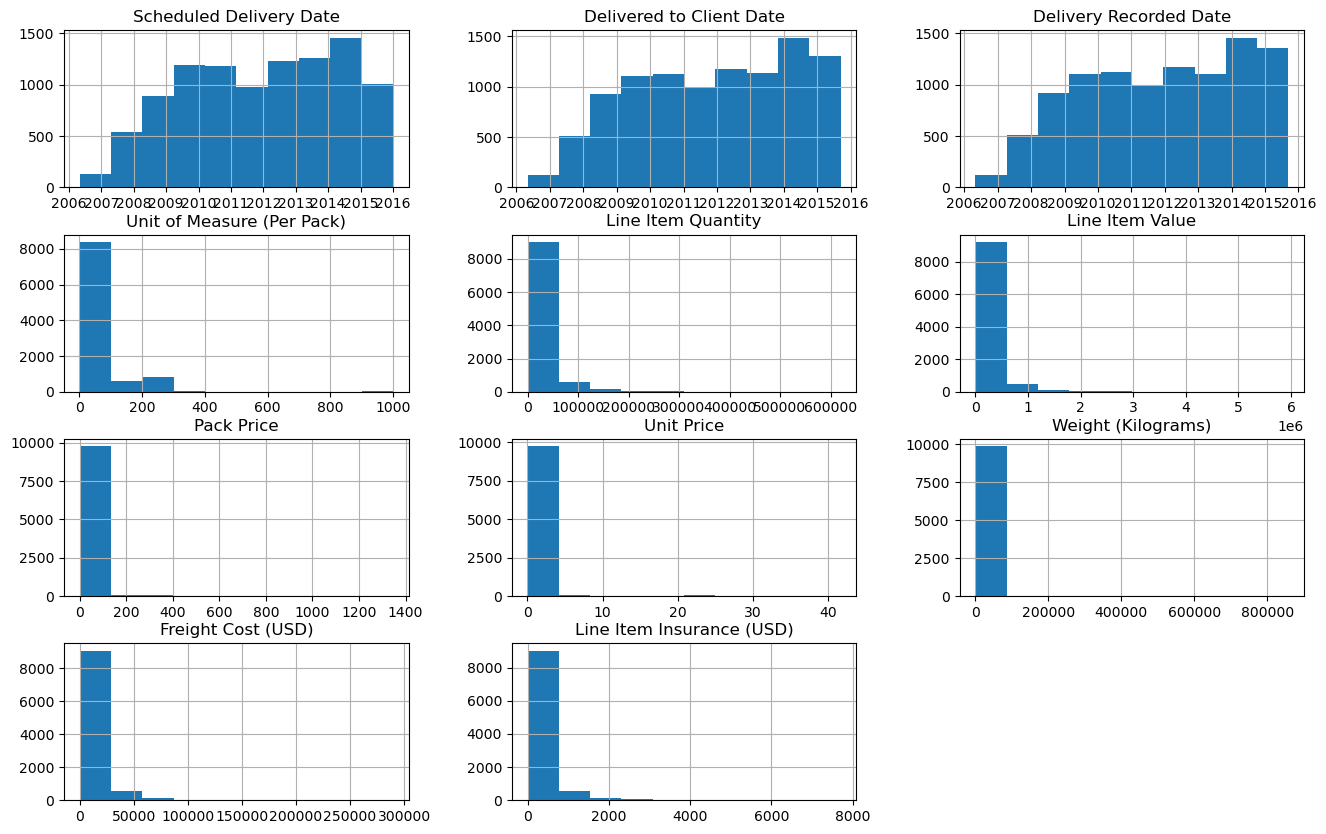

In [67]:
# Data Visualization Histogram for numerical columns 
df.hist(figsize=(16, 10))
plt.show()

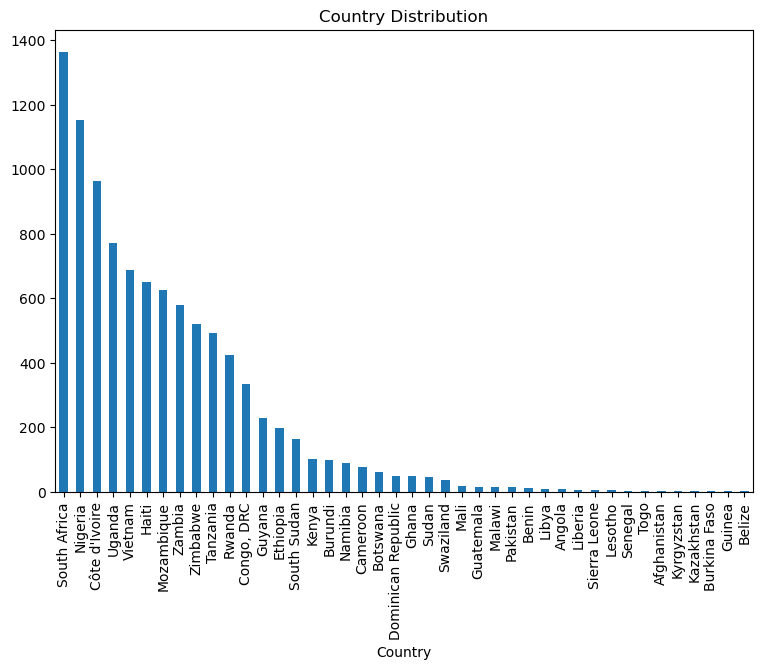

In [65]:
#Bar chart for categorical variables i recommended usi
plt.figure(figsize=(9, 6))
df['Country'].value_counts().plot(kind='bar')
plt.title("Country Distribution")
plt.show()


Text(0.5, 0, 'First Line Designation')

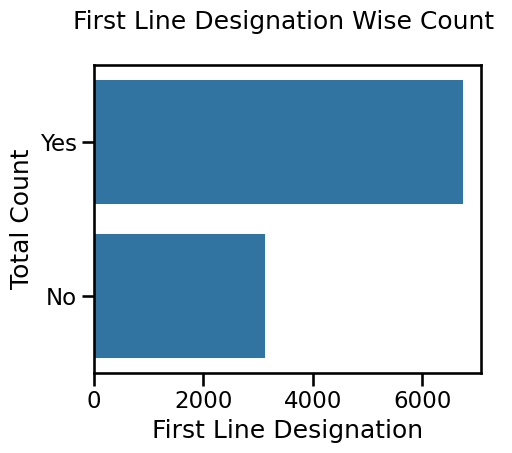

In [91]:
sns.set_context("talk",font_scale=1)
plt.figure(figsize=(5,4))
sns.countplot(df['First Line Designation'],order = df['First Line Designation'].value_counts().nlargest(10).index)
plt.title('First Line Designation Wise Count \n')
plt.ylabel('Total Count')
plt.xlabel('First Line Designation')

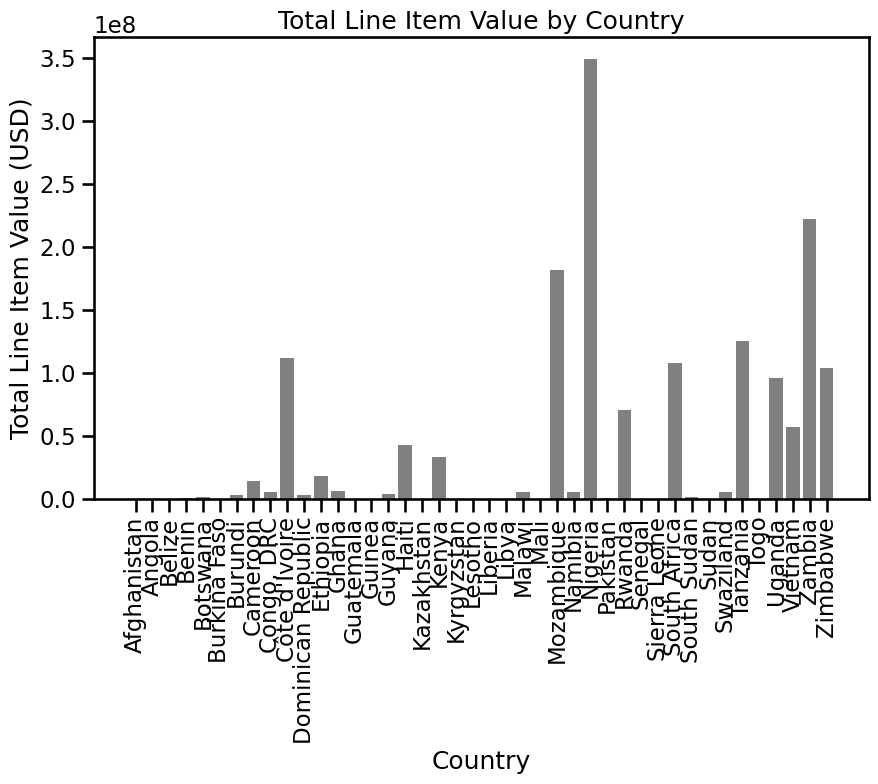

In [89]:
#  Bar plot of Line Item Values by Country
country_values = df.groupby('Country')['Line Item Value'].sum()
plt.figure(figsize=(10, 6))
plt.bar(country_values.index, country_values.values, color='gray')
plt.title('Total Line Item Value by Country')
plt.xlabel('Country')
plt.ylabel('Total Line Item Value (USD)')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

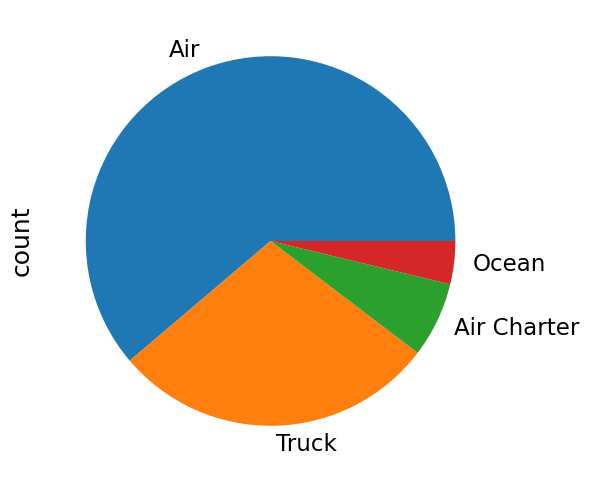

In [105]:
plt.figure(figsize=(9, 6))
df['Shipment Mode'].value_counts().plot(kind='pie')
plt.show()

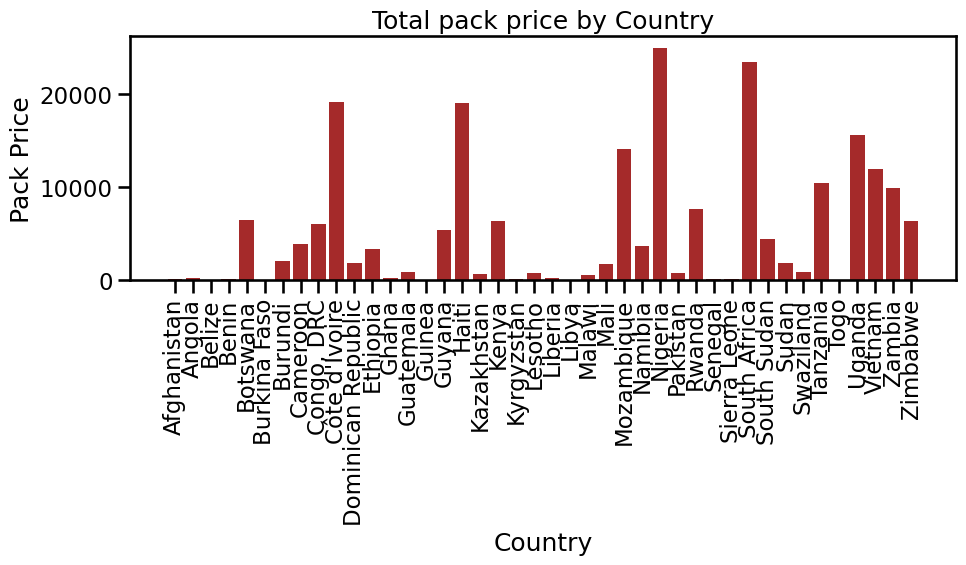

In [108]:
#  Bar plot of pack price by Country
country_pack_price = df.groupby('Country')['Pack Price'].sum()
plt.figure(figsize=(10, 6))
plt.bar(country_pack_price.index, country_pack_price.values, color='brown')
plt.title('Total pack price by Country')
plt.xlabel('Country')
plt.ylabel('Pack Price')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

## Export to Excel

In [43]:
df.to_excel('Supply chain pricing last update(2).xlsx',index=False,sheet_name='Data')